In [ ]:
import datetime
print(f"Last updated: {dat")

In [28]:
# Import necessary libraries
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.11.0'

In [29]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## Create a straight line dataset using the linear regression formula (`weight * X + bias`)
* weight=0.3, bias=0.9, 100 datapoints in total
* Split: 80% training, 20% testing
* plot training and testing data
  

In [30]:
# Create the data parameters
weight = 0.3
bias = 0.9

start = 0
end = 1
step = 0.01

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
# Make X and y using linear regression feature

print(f"Number of X samples: {len(X)}")
print(f"Number of Y samples: {len(y)}")
print(f"First 10 X & y samples:\nX: {X[:10]}\ny: {y[:10]}")

Number of X samples: 100
Number of Y samples: 100
First 10 X & y samples:
X: tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900]])
y: tensor([[0.9000],
        [0.9030],
        [0.9060],
        [0.9090],
        [0.9120],
        [0.9150],
        [0.9180],
        [0.9210],
        [0.9240],
        [0.9270]])


In [31]:
# Split the data into training and testing
train_split = int(0.8 * len(X))
X_train = X[:train_split]
y_train = y[:train_split]
X_test = X[train_split:]
y_test = y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(80, 80, 20, 20)

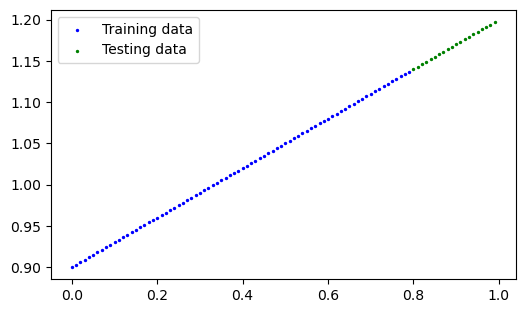

In [32]:
# Plot the training and testing data
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    plt.figure(figsize=(6, 3.5))
    plt.scatter(train_data, train_labels, c="b", s=2, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=2, label="Testing data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=2, label="Predictions")
    plt.legend(prop={"size": 10})
plot_predictions()

## 2. Build a Pytorch model by subclassing nn.Module
* inside should be a randomly initialized `nn.Parameter()` with `requires_grad=True`, one for `weights` and one for `bias`
* Implement the forward() method to compute the linear regression function you used to create the dataset in 1
* Once you've constructed the model, make an instance of it and check its `state_dict`.
* **Note:** If you'd like to use `nn.Linear()` instead of `nn.Parameter` you can.

In [51]:
# Create PyTorch linear regression modle by subclassing nn.Module
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)


OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [53]:
next(model_2.parameters()).device

device(type='cpu')

In [57]:
# Instantiate the model and put it to the target device

torch.manual_seed(42)
model_2 = LinearRegressionModel()
model_2.to(device)
next(model_2.parameters()).device



device(type='cpu')

In [58]:
model_2.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

### 3. Create a loss function and optimizer using `nn.L1Loss()` and `torch.optim.SGD(params, lr)` respectively.
* Set the leaerning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.
* Write a training loop to perform the appropriate training steps for 300 epochs.
* The training loop should test the model on the test dataset every 20 epochs

In [59]:
# Create the los function and optimizer
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

In [61]:
# Training loop
torch.manual_seed(42)

# Train model for 300 epochs
epochs = 300
# Send data to target device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    ### Training

    # Put model in train mode
    model_2.train()
    
    # 1. Forward pass
    y_pred = model_2(X_train)
    
    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)
    
    # 3. Zero gradients
    optimizer.zero_grad()
    
    # 4. Backpropagation
    loss.backward()
    
    # 5. Step the optimizer
    optimizer.step()
    
    ### Perform testing every 20 epochs
    if epoch % 20 == 0:
        # Put model in evaluation mode and setup inference context
        model_2.eval()

        with torch.inference_mode():
            # 1. Forward pass 
            test_pred = model_2(X_test)
            
            # 2. Calculate test loss
            test_loss = loss_fn(test_pred, y_test)
    
        # Print out what's happening
        print(f"Epoch: {epoch} | Train loss: {loss:.3f} | Testloss: {test_loss:.3f}")

Epoch: 0 | Train loss: 0.128 | Testloss: 0.337
Epoch: 20 | Train loss: 0.082 | Testloss: 0.218
Epoch: 40 | Train loss: 0.072 | Testloss: 0.175
Epoch: 60 | Train loss: 0.065 | Testloss: 0.153
Epoch: 80 | Train loss: 0.058 | Testloss: 0.137
Epoch: 100 | Train loss: 0.051 | Testloss: 0.121
Epoch: 120 | Train loss: 0.045 | Testloss: 0.104
Epoch: 140 | Train loss: 0.038 | Testloss: 0.088
Epoch: 160 | Train loss: 0.031 | Testloss: 0.072
Epoch: 180 | Train loss: 0.024 | Testloss: 0.056
Epoch: 200 | Train loss: 0.017 | Testloss: 0.040
Epoch: 220 | Train loss: 0.010 | Testloss: 0.024
Epoch: 240 | Train loss: 0.003 | Testloss: 0.007
Epoch: 260 | Train loss: 0.008 | Testloss: 0.007
Epoch: 280 | Train loss: 0.008 | Testloss: 0.007


### 4. Make predictions with the trained model on the test data.
* Visualize these predictions against the original training and testing data(**note:** you may need to make sure the predictions are not on the GPU if you want to use nonn-CUDA-enabled libraries such as matplotlib to plot)

In [62]:
# Make predictions with the model
model_2.eval()
with torch.inference_mode():
    y_preds_new = model_2(X_test)
y_preds_new

tensor([[1.1333],
        [1.1363],
        [1.1393],
        [1.1423],
        [1.1454],
        [1.1484],
        [1.1514],
        [1.1545],
        [1.1575],
        [1.1605],
        [1.1635],
        [1.1666],
        [1.1696],
        [1.1726],
        [1.1757],
        [1.1787],
        [1.1817],
        [1.1847],
        [1.1878],
        [1.1908]])

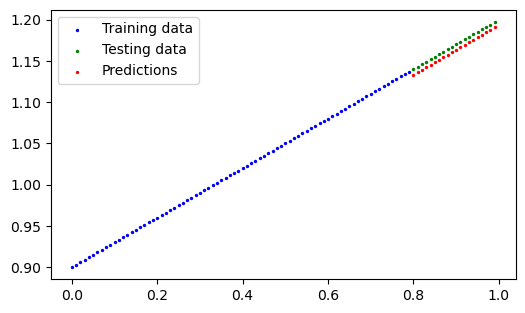

In [63]:
# Plot the predictions (these may need to be on a specific device)
plot_predictions(predictions=y_preds_new.cpu())

### 5. Save your trained model's `state_dict()` to file
* Create a new instance of your model class you made in 2. and load in the `state_dict()` you just saved to it.
* Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4.

In [64]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("exercise_models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "exercise_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")

# 3. Save the model state dict
torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: exercise_models/exercise_model_2.pth


In [66]:
# Create new instance of model and load saved state dict (make sure to put it on the target device)
loaded_model_2 = LinearRegressionModel()
loaded_model_2.load_state_dict(torch.load(MODEL_SAVE_PATH))

loaded_model_2.to(device)

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [68]:
model_2.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.3028]])),
             ('linear_layer.bias', tensor([0.8910]))])

In [69]:
loaded_model_2.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.3028]])),
             ('linear_layer.bias', tensor([0.8910]))])

In [67]:
next(loaded_model_2.parameters()).device

device(type='cpu')

In [73]:
# Make predictions with the loaded model and compare them to the previous
loaded_model_2.eval()
with torch.inference_mode():
    loaded_model_2_pred = loaded_model_2(X_test)
loaded_model_2_pred == y_preds_new

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])